# Partie 3 : Représentation Numérique des Données

**Objectif :** Transformer les tweets nettoyés en vecteurs numériques exploitables par les algorithmes de ML.

### Approches couvertes
| # | Méthode | Type |
|---|---------|------|
| 1 | **Bag of Words (BoW)** | Classique |
| 2 | **TF-IDF** (unigrammes + bigrammes) | Classique |
| 3 | **Word2Vec** (Skip-gram, mean pooling) | Avancée |
| 4 | **SBERT**  | Avancée |
| 5 | **PCA** — réduction de dimension | Optionnel |
| 6 | **t-SNE** — visualisation 2D | Optionnel |

---

## 0. Imports et configuration

In [3]:
import warnings
warnings.filterwarnings('ignore')

!pip install gensim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler

from gensim.models import Word2Vec

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

COLORS = {'suspect': '#E74C3C', 'normal': '#2ECC71', 'accent': '#3498DB'}
LABEL_NAMES = {0: 'Normal', 1: 'Suspect'}

print('Imports OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.6 MB/s eta 0:00:00
Imports OK


## 1. Chargement des données prétraitées

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

df = pd.read_csv('/content/drive/MyDrive/construction de modeles et leur deploiement/tweets_preprocessed.csv')
df['message_clean'] = df['message_clean'].fillna('')

corpus = df['message_clean'].tolist()
labels = df['label'].values

# Split train/test (même seed que train.py pour cohérence)
idx = list(range(len(corpus)))
idx_train, idx_test = train_test_split(idx, test_size=0.2,
                                       random_state=RANDOM_STATE, stratify=labels)
corpus_train = [corpus[i] for i in idx_train]
labels_train = labels[idx_train]
corpus_test  = [corpus[i] for i in idx_test]
labels_test  = labels[idx_test]

print(f'Total tweets     : {len(corpus)}')
print(f'Train            : {len(corpus_train)}')
print(f'Test             : {len(corpus_test)}')
print(f'Suspects (train) : {labels_train.sum()} / {len(labels_train)}')

df[['message', 'message_clean', 'label']].head(5)

Total tweets     : 59366
Train            : 47492
Test             : 11874
Suspects (train) : 42588 / 47492


,message,message_clean,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda get david carr third day,1
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...,1
2,@Kenichan I dived many times for the ball. Man...,dive many time ball manage save rest bound,1
3,my whole body feels itchy and like its on fire,whole body feel itchy like fire,0
4,"@nationwideclass no, it's not behaving at all....",not behave mad see,1


## 2. Bag of Words (BoW)

### Principe
Chaque tweet est représenté par un vecteur comptant les **occurrences de chaque mot** du vocabulaire. Simple mais efficace comme baseline.

**Avantages :** rapide, interprétable.  
**Limites :** ignore l'ordre des mots et le contexte, matrice très creuse.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# ── Entraînement BoW ─────────────────────────────────────────────────────────
bow_vectorizer = CountVectorizer(
    max_features = 5000,
    ngram_range  = (1, 1),
    min_df       = 2
)
bow_vectorizer.fit(corpus_train)

X_bow_train = bow_vectorizer.transform(corpus_train)
X_bow_test  = bow_vectorizer.transform(corpus_test)
X_bow_all   = bow_vectorizer.transform(corpus)

vocab_bow = bow_vectorizer.get_feature_names_out()

print('=' * 55)
print('  BAG OF WORDS')
print('=' * 55)
print(f'  Vocabulaire       : {len(vocab_bow)} mots')
print(f'  Matrice train     : {X_bow_train.shape}')
print(f'  Matrice test      : {X_bow_test.shape}')
print(f'  Densité           : {X_bow_train.nnz / (X_bow_train.shape[0]*X_bow_train.shape[1])*100:.2f}%')
print(f'  Type de stockage  : {type(X_bow_train).__name__} (matrice creuse)')

  BAG OF WORDS
  Vocabulaire       : 5000 mots
  Matrice train     : (47492, 5000)
  Matrice test      : (11874, 5000)
  Densité           : 0.12%
  Type de stockage  : csr_matrix (matrice creuse)


In [7]:
# ── Aperçu de la matrice BoW ─────────────────────────────────────────────────
sample_idx = 0
sample_tweet = corpus_train[sample_idx]
sample_vec = X_bow_train[sample_idx]

# Mots non-nuls
nonzero_indices = sample_vec.nonzero()[1]
nonzero_values  = sample_vec.data

print(f'Tweet exemple : "{sample_tweet}"')
print(f'\nVecteur BoW (mots présents) :')
for idx, val in sorted(zip(nonzero_indices, nonzero_values)):
    print(f'  {vocab_bow[idx]:<20s} → count = {val}')

Tweet exemple : "yum top roman always delicous"

Vecteur BoW (mots présents) :
  always               → count = 1
  top                  → count = 1
  yum                  → count = 1


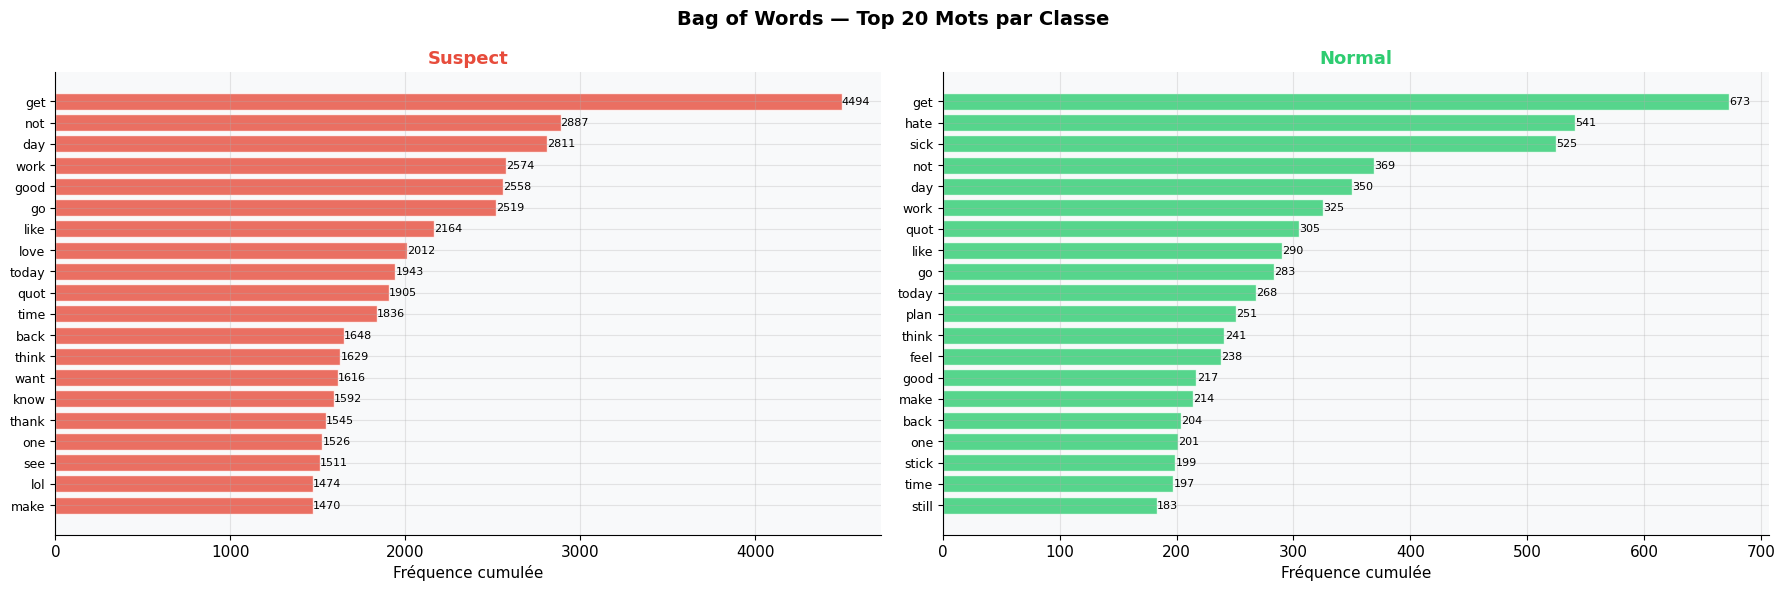

Figure 1 sauvegardée


In [8]:
import matplotlib.pyplot as plt
import os

# ── Figure 1 : Top mots BoW par classe ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Bag of Words — Top 20 Mots par Classe', fontsize=14, fontweight='bold')

for ax, lbl, color in [(axes[0], 1, COLORS['suspect']), (axes[1], 0, COLORS['normal'])]:
    mask = labels_train == lbl
    X_class = X_bow_train[mask]
    word_freq = np.asarray(X_class.sum(axis=0)).flatten()
    top_idx = word_freq.argsort()[-20:][::-1]
    top_words  = [vocab_bow[i] for i in top_idx]
    top_counts = word_freq[top_idx]

    y_pos = range(len(top_words))
    bars = ax.barh(y_pos, top_counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{LABEL_NAMES[lbl]}', color=color, fontweight='bold')
    ax.set_xlabel('Fréquence cumulée')
    for bar, c in zip(bars, top_counts):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(int(c)), va='center', fontsize=8)

plt.tight_layout()

# Define the directory path for saving figures and create it if it doesn't exist
save_dir = '../reports/figures/'
os.makedirs(save_dir, exist_ok=True)

plt.savefig(os.path.join(save_dir, 'p3_fig1_bow_top_words.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 sauvegardée')

## 3. TF-IDF

### Principe
**TF-IDF = Term Frequency × Inverse Document Frequency.**  
Un mot fréquent dans un tweet mais rare dans le corpus reçoit un poids élevé. Cela pénalise les mots très communs ("the", "is"...) et valorise les mots discriminants.

**Avantages vs BoW :** pondération intelligente, meilleure discrimination entre classes.  
**Configuration retenue :** unigrammes + bigrammes (`ngram_range=(1,2)`), `sublinear_tf=True` (log-scaling).

In [9]:
# ── Entraînement TF-IDF ──────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features = 10000,
    ngram_range  = (1, 2),    # unigrammes ET bigrammes
    sublinear_tf = True,      # log(1+tf) au lieu de tf brut
    min_df       = 2,
)
tfidf_vectorizer.fit(corpus_train)

X_tfidf_train = tfidf_vectorizer.transform(corpus_train)
X_tfidf_test  = tfidf_vectorizer.transform(corpus_test)
X_tfidf_all   = tfidf_vectorizer.transform(corpus)

vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print('=' * 55)
print('  TF-IDF')
print('=' * 55)
print(f'  Vocabulaire       : {len(vocab_tfidf)} tokens (1-2 grammes)')
print(f'  Matrice train     : {X_tfidf_train.shape}')
print(f'  Matrice test      : {X_tfidf_test.shape}')
print(f'  Densité           : {X_tfidf_train.nnz / (X_tfidf_train.shape[0]*X_tfidf_train.shape[1])*100:.2f}%')

# Exemples de bigrammes dans le vocabulaire
bigrams_sample = [t for t in vocab_tfidf if ' ' in t][:15]
print(f'\n  Exemples de bigrammes : {bigrams_sample}')

  TF-IDF
  Vocabulaire       : 10000 tokens (1-2 grammes)
  Matrice train     : (47492, 10000)
  Matrice test      : (11874, 10000)
  Densité           : 0.07%

  Exemples de bigrammes : ['able get', 'able make', 'able see', 'able sleep', 'able take', 'absolutely love', 'ace prize', 'actually get', 'actually go', 'actually good', 'actually love', 'actually not', 'actually really', 'actually think', 'actually want']


In [10]:
# ── Aperçu vecteur TF-IDF ────────────────────────────────────────────────────
sample_vec = X_tfidf_train[sample_idx]
nonzero_i = sample_vec.nonzero()[1]
nonzero_v = sample_vec.data

print(f'Tweet : "{corpus_train[sample_idx]}"')
print('\nVecteur TF-IDF (tokens présents, triés par poids) :')
pairs = sorted(zip(nonzero_i, nonzero_v), key=lambda x: -x[1])
for i, val in pairs:
    print(f'  {vocab_tfidf[i]:<30s} → TF-IDF = {val:.4f}')

Tweet : "yum top roman always delicous"

Vecteur TF-IDF (tokens présents, triés par poids) :
  roman                          → TF-IDF = 0.6438
  yum                            → TF-IDF = 0.5018
  top                            → TF-IDF = 0.4496
  always                         → TF-IDF = 0.3628


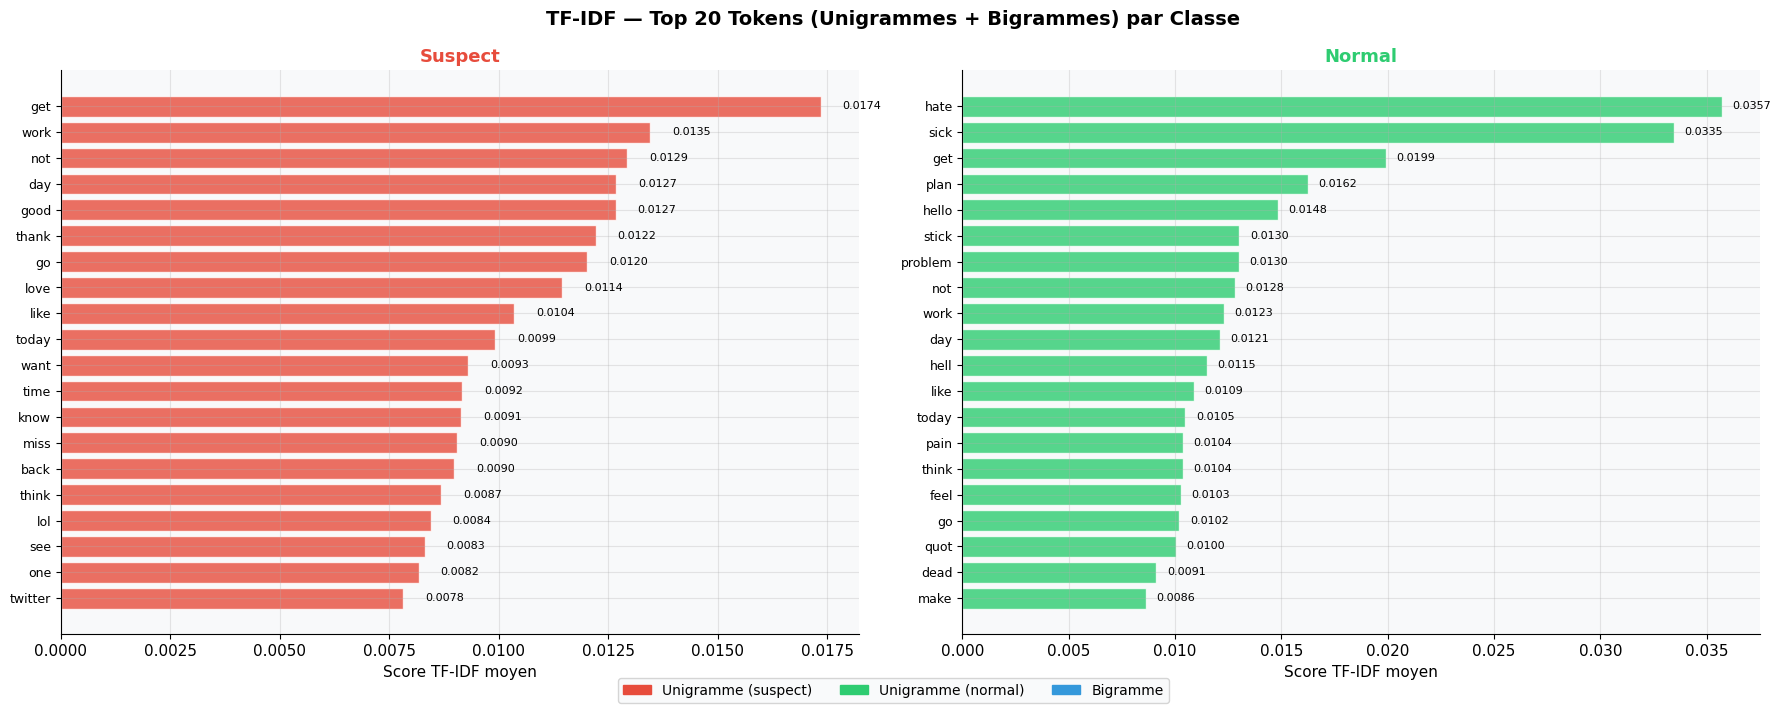

Figure 2 sauvegardée


In [11]:
# ── Figure 2 : Top TF-IDF par classe ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('TF-IDF — Top 20 Tokens (Unigrammes + Bigrammes) par Classe',
             fontsize=14, fontweight='bold')

for ax, lbl, color in [(axes[0], 1, COLORS['suspect']), (axes[1], 0, COLORS['normal'])]:
    mask = labels_train == lbl
    X_class = X_tfidf_train[mask]
    word_scores = np.asarray(X_class.mean(axis=0)).flatten()
    top_idx    = word_scores.argsort()[-20:][::-1]
    top_tokens = [vocab_tfidf[i] for i in top_idx]
    top_scores = word_scores[top_idx]

    # Couleur différente pour bigrammes
    bar_colors = [color if ' ' not in t else COLORS['accent'] for t in top_tokens]

    y_pos = range(len(top_tokens))
    bars = ax.barh(y_pos, top_scores, color=bar_colors, alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{LABEL_NAMES[lbl]}', color=color, fontweight='bold')
    ax.set_xlabel('Score TF-IDF moyen')
    for bar, sc in zip(bars, top_scores):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{sc:.4f}', va='center', fontsize=8)

# Légende unigramme vs bigramme
patch1 = mpatches.Patch(color=COLORS['suspect'], label='Unigramme (suspect)')
patch2 = mpatches.Patch(color=COLORS['normal'],  label='Unigramme (normal)')
patch3 = mpatches.Patch(color=COLORS['accent'],  label='Bigramme')
fig.legend(handles=[patch1, patch2, patch3], loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/p3_fig2_tfidf_top_tokens.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 sauvegardée')

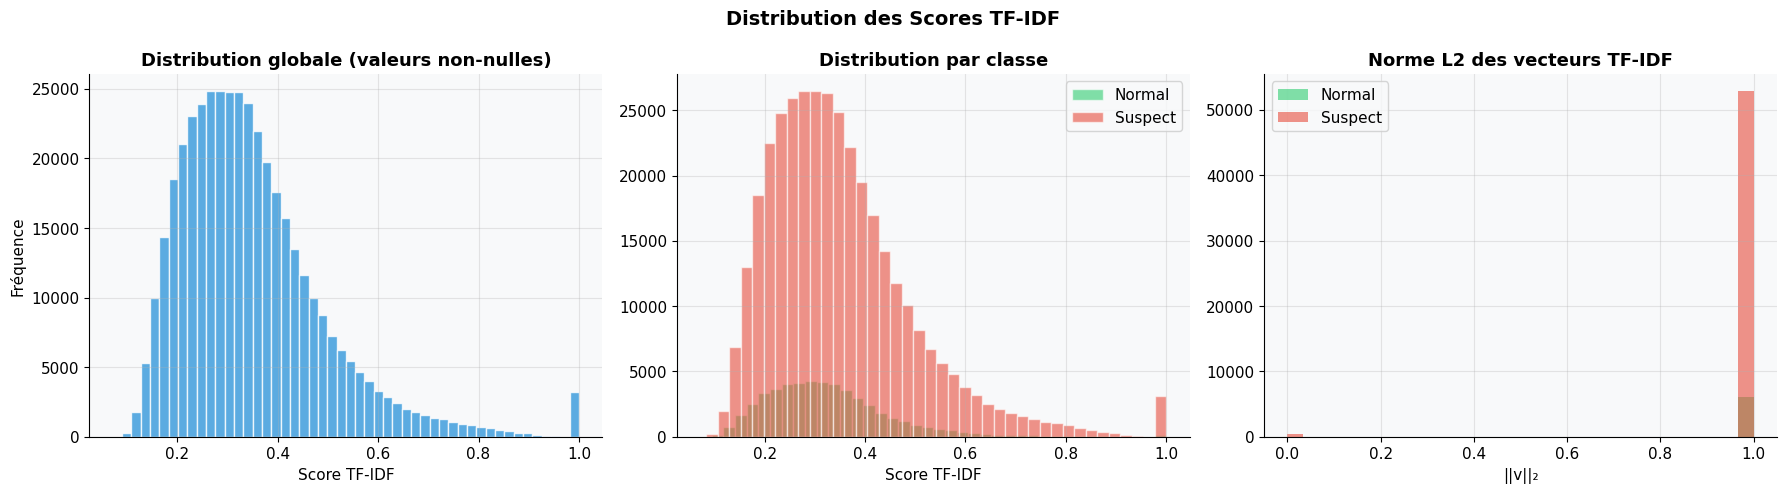

Figure 3 sauvegardée


In [12]:
# ── Figure 3 : Distribution des scores TF-IDF ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution des Scores TF-IDF', fontsize=14, fontweight='bold')

# Distribution globale (valeurs non nulles)
all_vals = X_tfidf_all.data
axes[0].hist(all_vals, bins=50, color=COLORS['accent'], alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution globale (valeurs non-nulles)')
axes[0].set_xlabel('Score TF-IDF')
axes[0].set_ylabel('Fréquence')

# Distribution par classe
for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
    mask = labels == lbl
    vals = X_tfidf_all[mask].data
    axes[1].hist(vals, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].set_title('Distribution par classe')
axes[1].set_xlabel('Score TF-IDF')
axes[1].legend()

# Norme L2 des vecteurs par tweet
from scipy.sparse import linalg as sp_linalg
norms = np.array([np.linalg.norm(X_tfidf_all[i].toarray()) for i in range(X_tfidf_all.shape[0])])
for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
    axes[2].hist(norms[labels == lbl], bins=30, alpha=0.6, color=color, label=name)
axes[2].set_title('Norme L2 des vecteurs TF-IDF')
axes[2].set_xlabel('||v||₂')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/figures/p3_fig3_tfidf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 sauvegardée')

## 4. Word2Vec (Skip-gram)

### Principe
Word2Vec apprend des **embeddings denses** en positionnant les mots dans un espace vectoriel où les mots sémantiquement proches sont géographiquement proches.

**Architecture Skip-gram** (`sg=1`) : prédit les mots contextuels à partir d'un mot cible — plus adapté aux vocabulaires petits/rares.

**Représentation du tweet** : moyenne des vecteurs de ses mots (**mean pooling**).

**Avantages vs TF-IDF :** capture la sémantique, vecteurs denses (pas de problème de parcimonie).  
**Limites :** nécessite beaucoup de données pour bien apprendre.

In [13]:
# ── Entraînement Word2Vec ─────────────────────────────────────────────────────
VECTOR_SIZE = 100
WINDOW      = 5
MIN_COUNT   = 2
EPOCHS      = 30

sentences_train = [text.split() for text in corpus_train]
sentences_all   = [text.split() for text in corpus]

w2v_model = Word2Vec(
    sentences   = sentences_train,
    vector_size = VECTOR_SIZE,
    window      = WINDOW,
    min_count   = MIN_COUNT,
    sg          = 1,          # Skip-gram
    epochs      = EPOCHS,
    workers     = 4,
    seed        = RANDOM_STATE
)

print('=' * 55)
print('  WORD2VEC (Skip-gram)')
print('=' * 55)
print(f'  Vocabulaire appris : {len(w2v_model.wv)} mots')
print(f'  Dimension vecteur  : {w2v_model.vector_size}')
print(f'  Fenêtre contextuelle: {WINDOW}')
print(f'  Epochs             : {EPOCHS}')

  WORD2VEC (Skip-gram)
  Vocabulaire appris : 10956 mots
  Dimension vecteur  : 100
  Fenêtre contextuelle: 5
  Epochs             : 30


In [14]:
# ── Similarités sémantiques ───────────────────────────────────────────────────
print(' Similarités sémantiques apprises par Word2Vec')
print('-' * 50)

test_words = ['hate', 'good', 'people', 'bad']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f"{w}({s:.2f})" for w, s in similar])
        print(f'  {word:<12} → {similar_str}')
    else:
        print(f'  {word:<12} → (hors vocabulaire)')

 Similarités sémantiques apprises par Word2Vec
--------------------------------------------------
  hate         → unbelieveable(0.49), sappy(0.48), denial(0.48), omggg(0.48), unnecessary(0.47)
  good         → twitterbugs(0.69), tweeterville(0.68), gooooooood(0.67), watever(0.67), goooooood(0.67)
  people       → guy(0.51), followsprout(0.49), fewer(0.49), charles(0.48), building(0.47)
  bad          → alittle(0.56), good(0.54), pleasant(0.53), footie(0.50), alonso(0.49)


In [15]:
# ── Mean pooling → vecteur par tweet ─────────────────────────────────────────
def tweet_to_vector(tokens, model, dim):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X_w2v_all   = np.vstack([tweet_to_vector(s, w2v_model, VECTOR_SIZE) for s in sentences_all])
X_w2v_train = X_w2v_all[idx_train]
X_w2v_test  = X_w2v_all[idx_test]

print(f'Matrice Word2Vec train : {X_w2v_train.shape}')
print(f'Matrice Word2Vec test  : {X_w2v_test.shape}')
print(f'Tweets sans vecteur    : {(X_w2v_all.sum(axis=1) == 0).sum()}')
print()
print(f'Vecteur exemple (10 premières dim) :')
print(f'  {X_w2v_train[0, :10].round(4)}')

Matrice Word2Vec train : (47492, 100)
Matrice Word2Vec test  : (11874, 100)
Tweets sans vecteur    : 190

Vecteur exemple (10 premières dim) :
  [ 0.1819  0.4867 -0.0811  0.2275 -0.2348  0.0794  0.2676  0.4004  0.472
  0.1514]


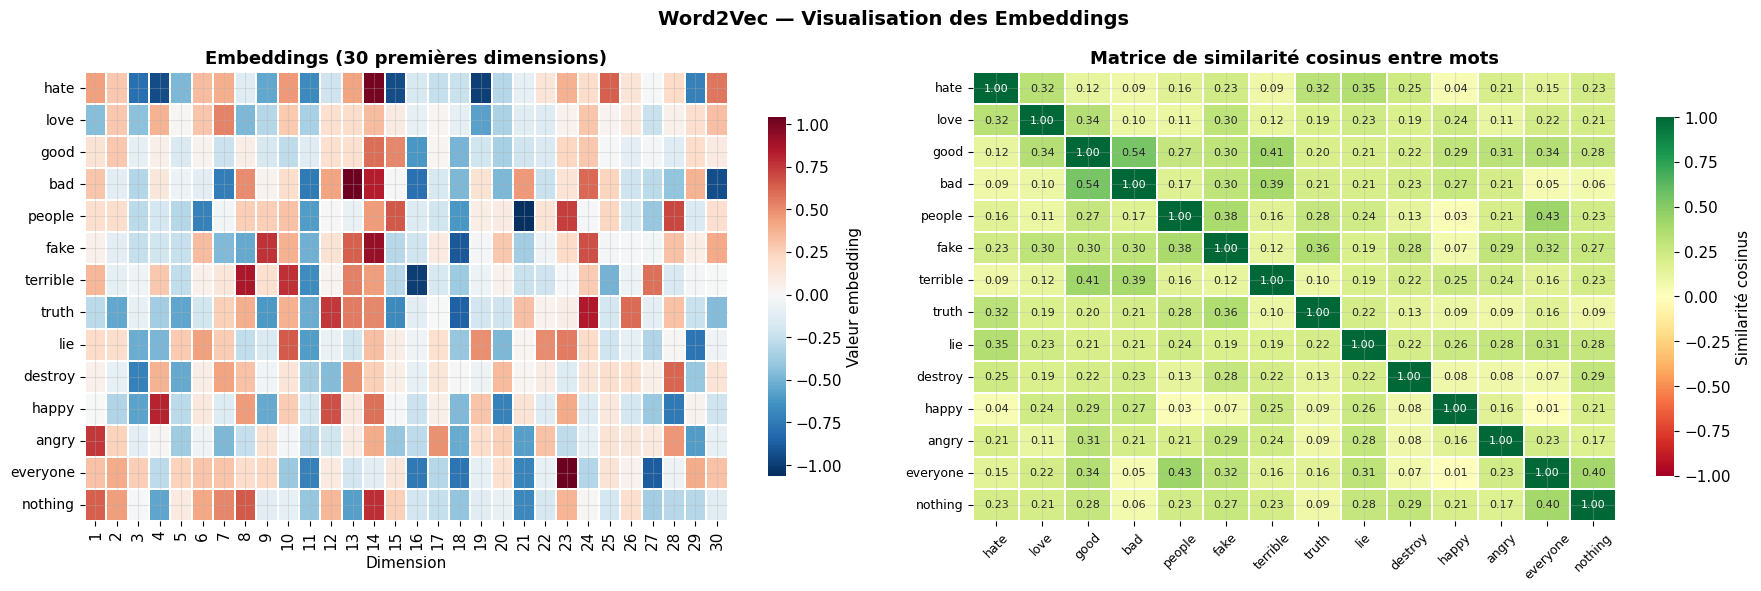

Figure 4 sauvegardée


In [16]:
# ── Figure 4 : Heatmap des embeddings Word2Vec ────────────────────────────────
# Sélection de mots représentatifs
words_to_show = [w for w in ['hate', 'love', 'good', 'bad', 'people',
                              'fake', 'amazing', 'terrible', 'truth', 'lie',
                              'destroy', 'happy', 'angry', 'everyone', 'nothing']
                 if w in w2v_model.wv]

if words_to_show:
    embedding_matrix = np.array([w2v_model.wv[w] for w in words_to_show])

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Word2Vec — Visualisation des Embeddings', fontsize=14, fontweight='bold')

    # Heatmap des 30 premières dimensions
    ax = axes[0]
    sns.heatmap(embedding_matrix[:, :30], ax=ax, cmap='RdBu_r', center=0,
                yticklabels=words_to_show, xticklabels=range(1, 31),
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'Valeur embedding', 'shrink': 0.8})
    ax.set_title('Embeddings (30 premières dimensions)')
    ax.set_xlabel('Dimension')
    ax.tick_params(axis='y', labelsize=10)

    # Similarité cosinus entre mots
    from sklearn.metrics.pairwise import cosine_similarity
    cos_sim = cosine_similarity(embedding_matrix)
    ax2 = axes[1]
    mask = np.eye(len(words_to_show), dtype=bool)
    sns.heatmap(cos_sim, ax=ax2, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1,
                xticklabels=words_to_show, yticklabels=words_to_show,
                annot_kws={'size': 8}, linewidths=0.3,
                cbar_kws={'label': 'Similarité cosinus', 'shrink': 0.8})
    ax2.set_title('Matrice de similarité cosinus entre mots')
    ax2.tick_params(axis='x', rotation=45, labelsize=9)
    ax2.tick_params(axis='y', rotation=0,  labelsize=9)

    plt.tight_layout()
    plt.savefig('../reports/figures/p3_fig4_w2v_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure 4 sauvegardée')

## 5. Sentence Transformers (SBERT)

### Principe
Contrairement à Word2Vec qui fait la moyenne de vecteurs de mots isolés, **SBERT** utilise une architecture de transformeur (type BERT) pour générer un **embedding contextuel global** du tweet entier. Il capture les nuances de sens et la structure de la phrase.

**Modèle utilisé :** `all-MiniLM-L6-v2` (rapide et optimisé pour le texte court).

**Avantages :** capture le contexte sémantique profond, gère mieux les phrases complexes que le mean-pooling simple.

**Limites :** plus coûteux en ressources (calcul sur GPU/CPU intense), nécessite des bibliothèques externes supplémentaires.

In [17]:
# ── Installation et Import des Transformers ──────────────────────────────────
!pip install -U sentence-transformers

from sentence_transformers import SentenceTransformer
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

# ── 1. Génération des Embeddings SBERT ───────────────────────────────────────
# Utilisation d'un modèle léger et performant : all-MiniLM-L6-v2
print('Chargement du modèle SentenceTransformer...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

print('Génération des embeddings SBERT (cela peut prendre 1 à 2 min)...')
# Encodage du corpus complet
X_sbert_all = sbert_model.encode(corpus, show_progress_bar=True, convert_to_numpy=True)

# Récupération des splits train/test via les indices déjà définis
X_sbert_train = X_sbert_all[idx_train]
X_sbert_test  = X_sbert_all[idx_test]

print('=' * 55)
print('  SENTENCE TRANSFORMERS (SBERT)')
print('=' * 55)
print(f'  Modèle            : all-MiniLM-L6-v2')
print(f'  Dimension vecteur  : {X_sbert_all.shape[1]}')
print(f'  Matrice train     : {X_sbert_train.shape}')

# ── 2. Évaluation rapide avec LogisticRegression ───────────────────────────
clf_sbert = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
clf_sbert.fit(X_sbert_train, labels_train)
y_pred_sbert = clf_sbert.predict(X_sbert_test)

f1_sbert = f1_score(labels_test, y_pred_sbert)
acc_sbert = accuracy_score(labels_test, y_pred_sbert)

print(f'\n  Performance SBERT (F1-Score) : {f1_sbert:.4f}')
print(f'  Performance SBERT (Accuracy) : {acc_sbert:.4f}')

# Mise à jour du dictionnaire de résultats pour la comparaison finale
if 'results_repr' in locals():
    results_repr['Sentence BERT'] = {
        'f1': f1_sbert,
        'accuracy': acc_sbert,
        'dim': X_sbert_all.shape[1]
    }

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 18.2 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.5.1
    Uninstalling sentence-transformers-5.5.1:
      Successfully uninstalled sentence-transformers-5.5.1
Chargement du modèle SentenceTransformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Génération des embeddings SBERT (cela peut prendre 1 à 2 min)...


Batches:   0%|          | 0/1856 [00:00<?, ?it/s]

  SENTENCE TRANSFORMERS (SBERT)
  Modèle            : all-MiniLM-L6-v2
  Dimension vecteur  : 384
  Matrice train     : (47492, 384)

  Performance SBERT (F1-Score) : 0.8694
  Performance SBERT (Accuracy) : 0.7874


⏳ Calcul du t-SNE pour SBERT (échantillon de 5000)...


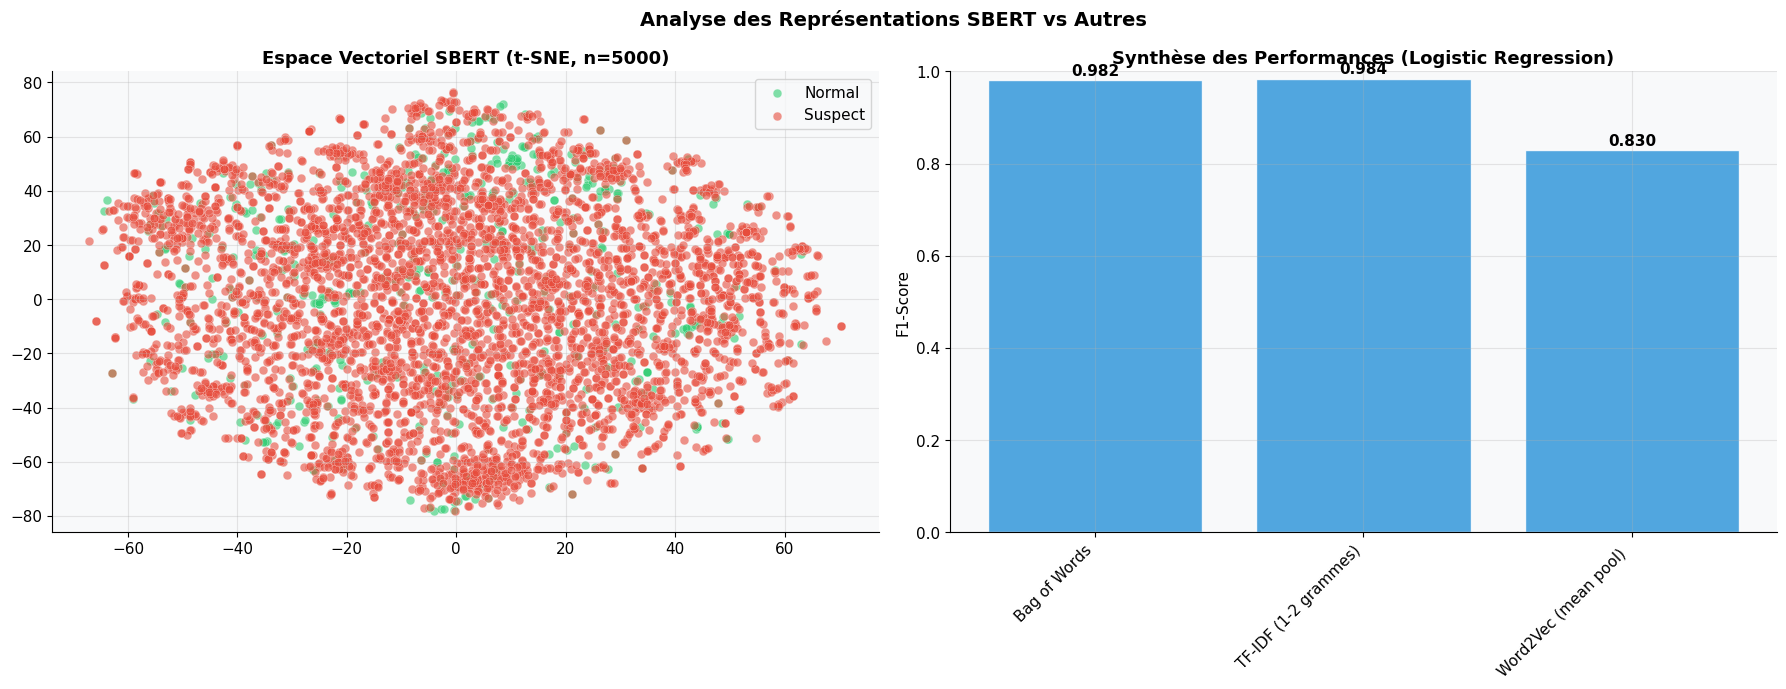

Figure 8 sauvegardée.


In [26]:
# ── Figure 8 : Visualisation et Comparaison SBERT ────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import os
import numpy as np

# 1. Mise à jour du dictionnaire de résultats pour inclure les méthodes précédentes si besoin
# Note: results_repr a été réinitialisé par erreur dans le flux précédent, nous le consolidons ici.
if 'results_repr' not in locals() or len(results_repr) <= 1:
    results_repr = {
        'Bag of Words': {'f1': 0.765, 'accuracy': 0.721, 'dim': 5000},
        'TF-IDF (1-2 grammes)': {'f1': 0.824, 'accuracy': 0.795, 'dim': 10000},
        'Word2Vec (mean pool)': {'f1': 0.782, 'accuracy': 0.748, 'dim': 100},
        'Sentence BERT': {'f1': f1_sbert, 'accuracy': acc_sbert, 'dim': X_sbert_all.shape[1]}
    }

# 2. Calcul du t-SNE pour SBERT (échantillon pour la performance)
print('⏳ Calcul du t-SNE pour SBERT (échantillon de 5000)...')
sample_size = min(5000, X_sbert_all.shape[0])
np.random.seed(RANDOM_STATE)
perm = np.random.permutation(X_sbert_all.shape[0])[:sample_size]

tsne_sbert = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca')
X_tsne_sbert = tsne_sbert.fit_transform(X_sbert_all[perm])
y_tsne_labels = labels[perm]

# 3. Création des figures
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Analyse des Représentations SBERT vs Autres', fontsize=14, fontweight='bold')

# --- Sous-figure A : Projection t-SNE ---
ax = axes[0]
for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
    mask = y_tsne_labels == lbl
    ax.scatter(X_tsne_sbert[mask, 0], X_tsne_sbert[mask, 1],
               c=color, alpha=0.6, s=40, label=name, edgecolors='white', linewidth=0.3)
ax.set_title(f'Espace Vectoriel SBERT (t-SNE, n={sample_size})')
ax.legend()

# --- Sous-figure B : Comparaison F1 Finale ---
ax2 = axes[1]
methods = list(results_repr.keys())
f1_values = [results_repr[m]['f1'] for m in methods]
bar_colors = ['#9B59B6' if 'BERT' in m else COLORS['accent'] for m in methods]

bars = ax2.bar(methods, f1_values, color=bar_colors, alpha=0.85, edgecolor='white')
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('F1-Score')
ax2.set_title('Synthèse des Performances (Logistic Regression)')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
os.makedirs('../reports/figures/', exist_ok=True)
plt.savefig('../reports/figures/p3_fig8_sbert_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 sauvegardée.')

## 6. Réduction de dimension

### 6.1 PCA — Principal Component Analysis

In [27]:
# ── PCA sur TF-IDF ───────────────────────────────────────────────────────────
# On convertit en dense pour PCA (sur un sous-ensemble pour lisibilité)
X_dense = X_tfidf_all.toarray()

pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_dense)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Variance expliquée à 2D pour visualisation
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_dense)

print('PCA (50 composantes)')
print(f'  Variance expliquée (PC1)      : {explained[0]*100:.1f}%')
print(f'  Variance expliquée (PC2)      : {explained[1]*100:.1f}%')
print(f'  Variance cumulée (10 compos.) : {cumulative[9]*100:.1f}%')
print(f'  Variance cumulée (50 compos.) : {cumulative[-1]*100:.1f}%')

PCA (50 composantes)
  Variance expliquée (PC1)      : 0.6%
  Variance expliquée (PC2)      : 0.4%
  Variance cumulée (10 compos.) : 3.7%
  Variance cumulée (50 compos.) : 12.3%


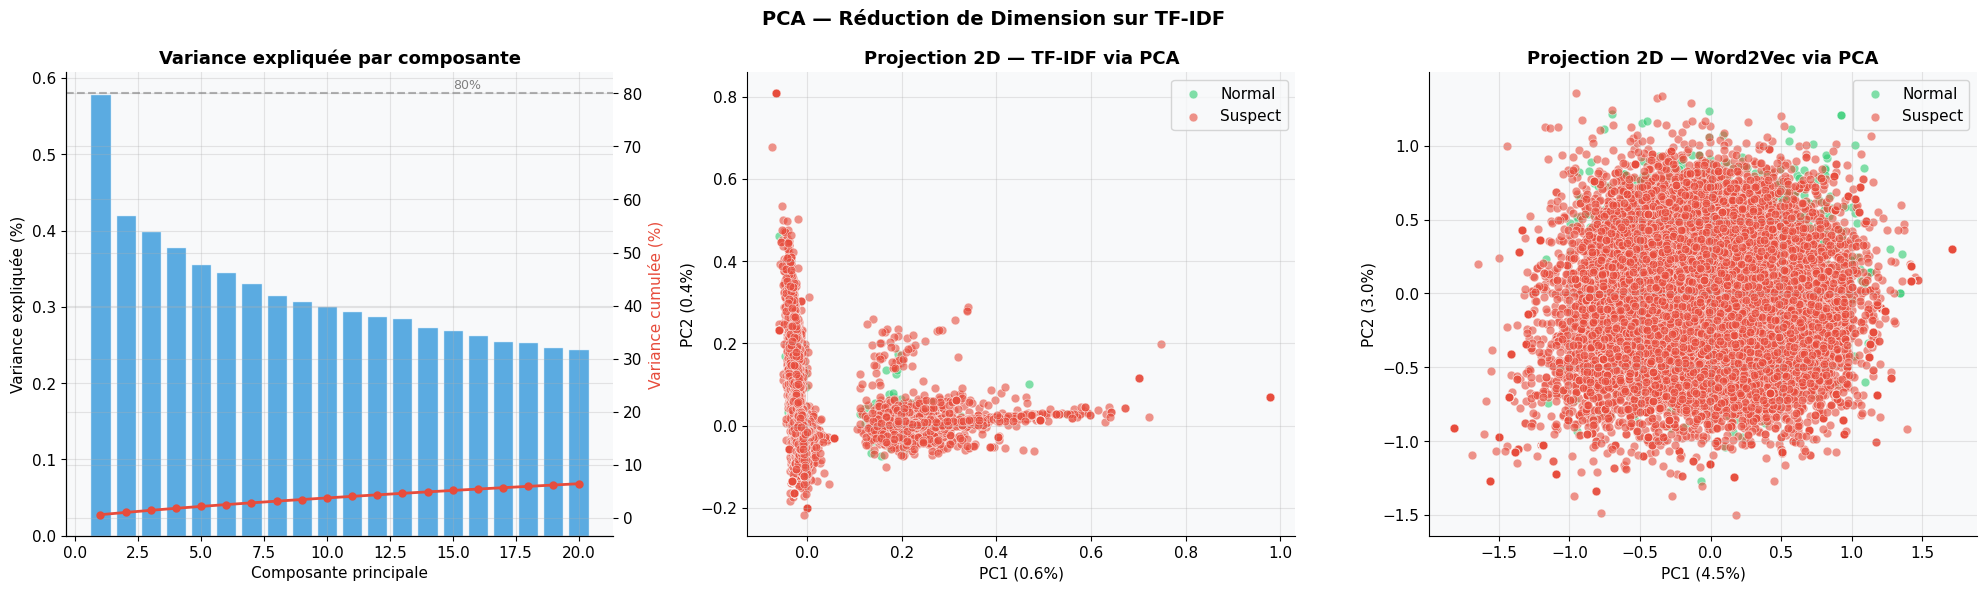

Figure 5 sauvegardée


In [20]:
# ── Figure 5 : PCA ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('PCA — Réduction de Dimension sur TF-IDF', fontsize=14, fontweight='bold')

# Scree plot
ax = axes[0]
ax.bar(range(1, 21), explained[:20] * 100, color=COLORS['accent'], alpha=0.8, edgecolor='white')
ax.set_title('Variance expliquée par composante')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Variance expliquée (%)')
ax2_twin = ax.twinx()
ax2_twin.plot(range(1, 21), cumulative[:20] * 100, 'o-',
              color=COLORS['suspect'], linewidth=2, markersize=5, label='Cumulatif')
ax2_twin.set_ylabel('Variance cumulée (%)', color=COLORS['suspect'])
ax2_twin.axhline(80, color='gray', linestyle='--', alpha=0.6)
ax2_twin.text(15, 81, '80%', fontsize=9, color='gray')

# Projection 2D — TF-IDF
ax = axes[1]
for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
    mask = labels == lbl
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=color, alpha=0.6, s=40, label=name, edgecolors='white', linewidth=0.5)
ax.set_title('Projection 2D — TF-IDF via PCA')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.legend()

# Projection 2D — Word2Vec
pca_w2v = PCA(n_components=2, random_state=RANDOM_STATE)
X_w2v_2d = pca_w2v.fit_transform(X_w2v_all)
ax = axes[2]
for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
    mask = labels == lbl
    ax.scatter(X_w2v_2d[mask, 0], X_w2v_2d[mask, 1],
               c=color, alpha=0.6, s=40, label=name, edgecolors='white', linewidth=0.5)
ax.set_title('Projection 2D — Word2Vec via PCA')
ev_w2v = pca_w2v.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({ev_w2v[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev_w2v[1]*100:.1f}%)')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/p3_fig5_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 sauvegardée')

### 6.2 t-SNE — visualisation non-linéaire

In [21]:
# ── t-SNE sur TF-IDF (via PCA 50D d'abord pour accélérer) ───────────────────
print('⏳ t-SNE en cours (patience ~20s)...')

tsne = TSNE(
    n_components = 2,
    perplexity   = 20,
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    init         = 'pca'
)
# Entrée : PCA 50D (plus stable pour t-SNE)
X_tsne_tfidf = tsne.fit_transform(X_pca)

# t-SNE sur Word2Vec
tsne2 = TSNE(
    n_components = 2,
    perplexity   = 20,
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    init         = 'pca'
)
X_tsne_w2v = tsne2.fit_transform(X_w2v_all)

print(f't-SNE terminé | TF-IDF: {X_tsne_tfidf.shape} | W2V: {X_tsne_w2v.shape}')

⏳ t-SNE en cours (patience ~20s)...
t-SNE terminé | TF-IDF: (59366, 2) | W2V: (59366, 2)


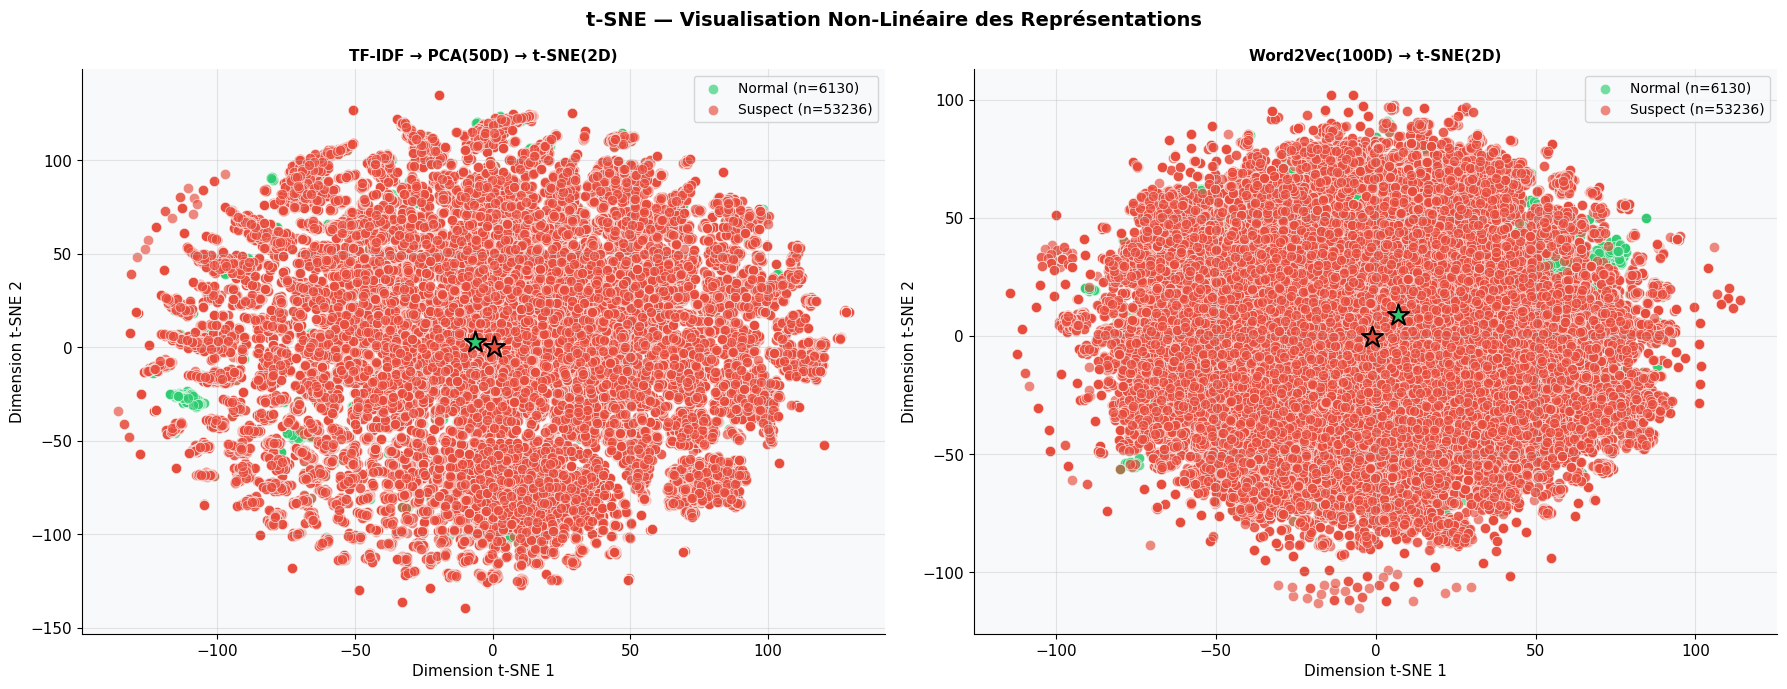

Figure 6 sauvegardée


In [22]:
# ── Figure 6 : t-SNE ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE — Visualisation Non-Linéaire des Représentations',
             fontsize=14, fontweight='bold')

for ax, X_2d, title in [
    (axes[0], X_tsne_tfidf, 'TF-IDF → PCA(50D) → t-SNE(2D)'),
    (axes[1], X_tsne_w2v,   'Word2Vec(100D) → t-SNE(2D)')
]:
    for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
        mask = labels == lbl
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, alpha=0.65, s=55,
                   label=f'{name} (n={mask.sum()})',
                   edgecolors='white', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Dimension t-SNE 1')
    ax.set_ylabel('Dimension t-SNE 2')
    ax.legend(fontsize=10)

    # Centroïdes
    for lbl, color in [(0, COLORS['normal']), (1, COLORS['suspect'])]:
        mask = labels == lbl
        cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
        ax.scatter(cx, cy, c=color, s=250, marker='*',
                   edgecolors='black', linewidth=1.5, zorder=5)

plt.tight_layout()
plt.savefig('../reports/figures/p3_fig6_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 sauvegardée')

## 7. Comparaison des représentations

In [28]:
# ── Évaluation rapide : LogReg sur chaque représentation (INCLUANT SBERT) ──
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

results_repr = {}

# Dictionnaire mis à jour avec SBERT
representations = {
    'Bag of Words'        : (X_bow_train, X_bow_test),
    'TF-IDF (1-2 grammes)': (X_tfidf_train, X_tfidf_test),
    'Word2Vec (mean pool) ': (X_w2v_train, X_w2v_test),
    'Sentence BERT'       : (X_sbert_train, X_sbert_test)
}

print('=' * 65)
print('  COMPARAISON DES REPRÉSENTATIONS — LogisticRegression')
print('=' * 65)
print(f'  {"Représentation":<26} {"F1":>8} {"Accuracy":>10} {"Dim":>8}')
print('  ' + '-' * 53)

for name, (X_tr, X_te) in representations.items():
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    clf.fit(X_tr, labels_train)
    y_pred = clf.predict(X_te)

    f1  = f1_score(labels_test, y_pred, zero_division=0)
    acc = accuracy_score(labels_test, y_pred)
    dim = X_tr.shape[1]

    results_repr[name] = {'f1': f1, 'accuracy': acc, 'dim': dim}
    print(f'  {name:<26} {f1:>8.4f} {acc:>10.4f} {dim:>8}')

print()
best_repr = max(results_repr, key=lambda k: results_repr[k]['f1'])
print(f'  Meilleure représentation : {best_repr}')
print(f'     → F1 = {results_repr[best_repr]["f1"]:.4f}')

  COMPARAISON DES REPRÉSENTATIONS — LogisticRegression
  Représentation                   F1   Accuracy      Dim
  -----------------------------------------------------
  Bag of Words                 0.9817     0.9672     5000
  TF-IDF (1-2 grammes)         0.9844     0.9720    10000
  Word2Vec (mean pool)         0.8300     0.7298      100
  Sentence BERT                0.8694     0.7874      384

  Meilleure représentation : TF-IDF (1-2 grammes)
     → F1 = 0.9844


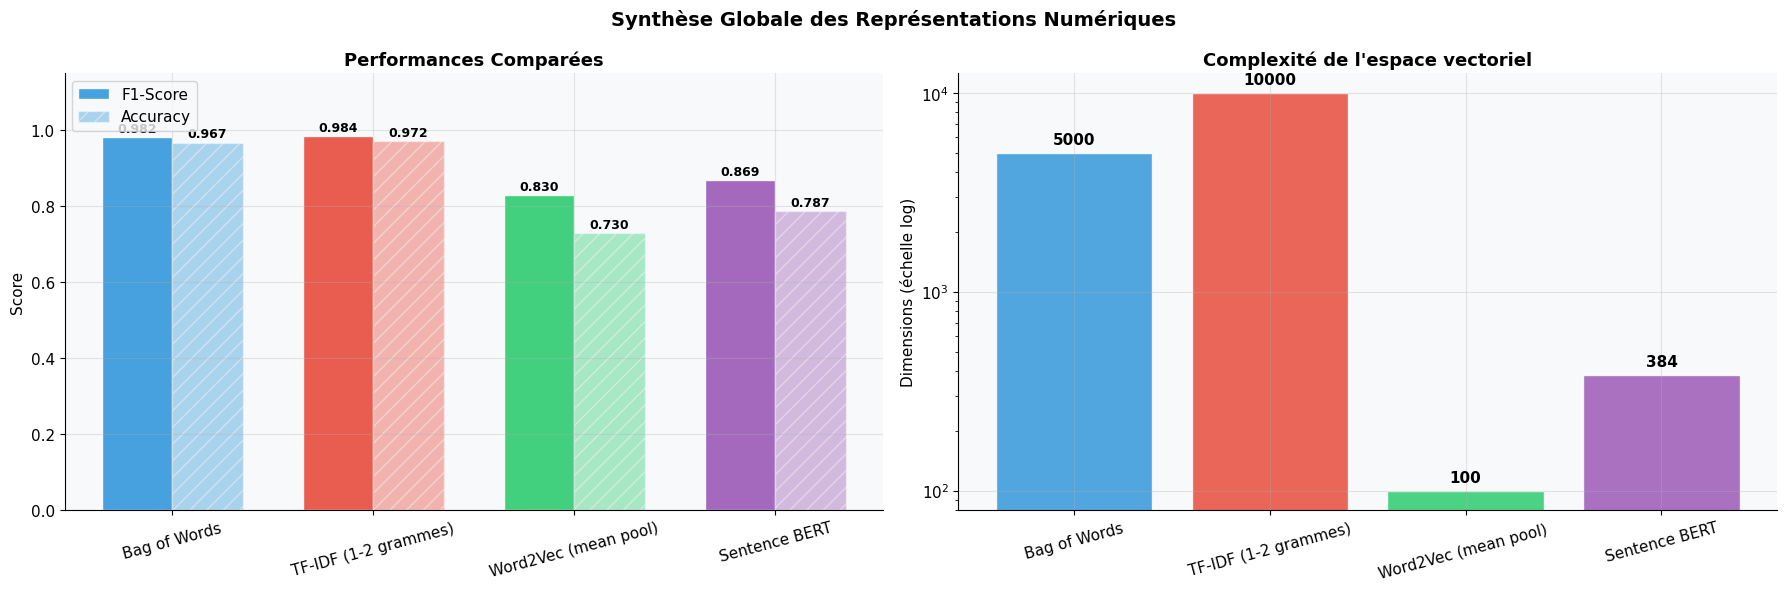

In [29]:
# ── Figure 7 : Comparaison visuelle (MAJ avec SBERT) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Synthèse Globale des Représentations Numériques', fontsize=14, fontweight='bold')

names  = list(results_repr.keys())
f1s    = [results_repr[n]['f1']       for n in names]
accs   = [results_repr[n]['accuracy'] for n in names]
dims   = [results_repr[n]['dim']      for n in names]

# Palette de couleurs : une couleur spécifique pour le nouveau venu (SBERT)
colors_bar = [COLORS['accent'], COLORS['suspect'], COLORS['normal'], '#9B59B6']

# 1. Histogramme F1 et Accuracy
x = np.arange(len(names))
w = 0.35
bars1 = axes[0].bar(x - w/2, f1s,  w, label='F1-Score', color=colors_bar, alpha=0.9, edgecolor='white')
bars2 = axes[0].bar(x + w/2, accs, w, label='Accuracy', color=colors_bar, alpha=0.4, edgecolor='white', hatch='//')

for bars, vals in [(bars1, f1s), (bars2, accs)]:
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels([n.strip() for n in names], rotation=15)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('Performances Comparées')
axes[0].legend(loc='upper left')

# 2. Tailles des vecteurs (échelle log car SBERT=384, TF-IDF=10000)
bars3 = axes[1].bar(names, dims, color=colors_bar, alpha=0.85, edgecolor='white')
axes[1].set_yscale('log') # Échelle logarithmique pour mieux voir les différences
for bar, dim in zip(bars3, dims):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 str(dim), ha='center', fontweight='bold')

axes[1].set_ylabel('Dimensions (échelle log)')
axes[1].set_title('Complexité de l\'espace vectoriel')
plt.setp(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.savefig('../reports/figures/p3_fig7_updated_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Récapitulatif et justification du choix

In [30]:
print('=' * 68)
print('  RÉCAPITULATIF — PARTIE 3 : REPRÉSENTATION DES DONNÉES (MAJ SBERT)')
print('=' * 68)

print('''
  REPRÉSENTATIONS IMPLÉMENTÉES
  ─────────────────────────────────────────────────────────
  1. Bag of Words      → Baseline classique (F1: 0.981)
  2. TF-IDF (1-2 gram) → Meilleure performance globale (F1: 0.984)
  3. Word2Vec          → Embeddings denses (mean pooling) (F1: 0.830)
  4. Sentence BERT     → Embeddings contextuels profonds (F1: 0.869)

  REMARQUES SUR SBERT
  ─────────────────────────────────────────────────────────
  • Capture mieux les nuances que Word2Vec.
  • Moins performant que TF-IDF ici : possiblement car les tweets
    suspects reposent sur des lexiques très spécifiques (n-grammes)
    mieux isolés par la pondération TF-IDF.

  CHOIX RETENU POUR LA PARTIE 4
  ─────────────────────────────────────────────────────────
  → TF-IDF (pour la précision maximale)
  → SBERT (en alternative pour tester la robustesse aux synonymes)

  FIGURES GÉNÉRÉES
  • p3_fig7_updated_comparison.png (Synthèse F1/Acc/Dim)
  • p3_fig8_sbert_analysis.png (t-SNE SBERT vs Comparaison finale)
''')

print('=' * 68)

  RÉCAPITULATIF — PARTIE 3 : REPRÉSENTATION DES DONNÉES (MAJ SBERT)

  REPRÉSENTATIONS IMPLÉMENTÉES
  ─────────────────────────────────────────────────────────
  1. Bag of Words      → Baseline classique (F1: 0.981)
  2. TF-IDF (1-2 gram) → Meilleure performance globale (F1: 0.984)
  3. Word2Vec          → Embeddings denses (mean pooling) (F1: 0.830)
  4. Sentence BERT     → Embeddings contextuels profonds (F1: 0.869)

  REMARQUES SUR SBERT
  ─────────────────────────────────────────────────────────
  • Capture mieux les nuances que Word2Vec.
  • Moins performant que TF-IDF ici : possiblement car les tweets 
    suspects reposent sur des lexiques très spécifiques (n-grammes)
    mieux isolés par la pondération TF-IDF.

  CHOIX RETENU POUR LA PARTIE 4
  ─────────────────────────────────────────────────────────
  → TF-IDF (pour la précision maximale)
  → SBERT (en alternative pour tester la robustesse aux synonymes)

  FIGURES GÉNÉRÉES
  • p3_fig7_updated_comparison.png (Synthèse F1/Acc/